In [62]:

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.preprocessing.sequence import pad_sequences
import torch
from torch.utils.data import Dataset, DataLoader

In [63]:
sequences = []

with open("/content/1000_calls.txt", "r") as f:
    for line in f:
        if line.strip():
            seq = list(map(int, line.strip().split(',')))
            sequences.append(seq)

print("Total sequences:", len(sequences))

Total sequences: 7107


In [64]:

print("First sequence length:", len(sequences[0]))
print("First 10 numbers:", sequences[0][:10])

First sequence length: 287
First 10 numbers: [292, 291, 292, 291, 291, 291, 291, 291, 291, 291]


In [65]:
labels = []

with open("/content/labels.txt", "r") as f:
    for line in f:
        if line.strip():
            labels.append(line.strip())

print("Total labels:", len(labels))

Total labels: 7107


In [66]:
print(len(sequences), len(labels))

7107 7107


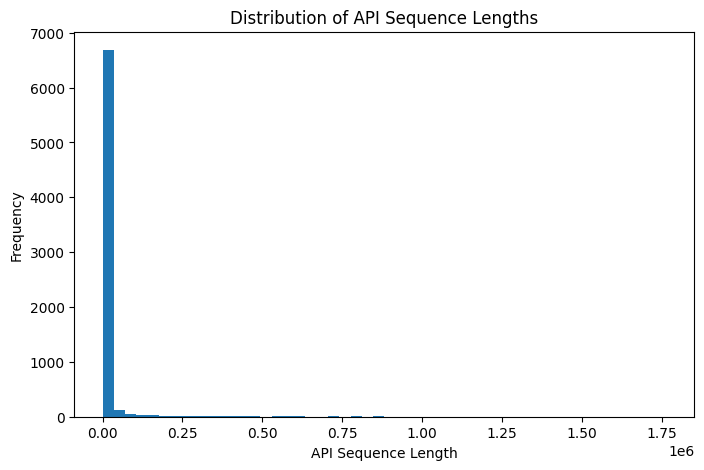

In [67]:
import matplotlib.pyplot as plt

# Compute sequence lengths
seq_lengths = [len(seq) for seq in sequences]

plt.figure(figsize=(8,5))
plt.hist(seq_lengths, bins=50)

plt.xlabel("API Sequence Length")
plt.ylabel("Frequency")
plt.title("Distribution of API Sequence Lengths")

plt.savefig("sequence_length_distribution.pdf", bbox_inches='tight')

plt.show()

In [68]:
from google.colab import files
files.download("sequence_length_distribution.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [69]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(labels)

print("Classes:", le.classes_)
print("Number of classes:", len(le.classes_))

Classes: ['Adware' 'Backdoor' 'Downloader' 'Dropper' 'Spyware' 'Trojan' 'Virus'
 'Worms']
Number of classes: 8


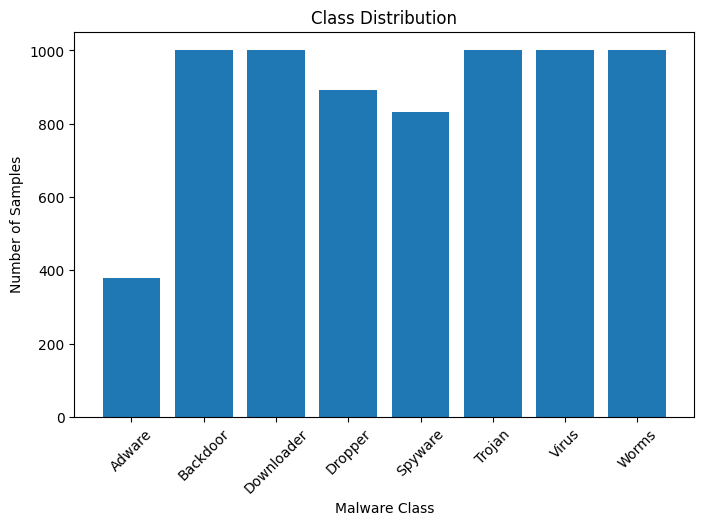

In [70]:
import numpy as np
import matplotlib.pyplot as plt

unique, counts = np.unique(y, return_counts=True)

plt.figure(figsize=(8,5))

plt.bar(le.classes_, counts)

plt.xticks(rotation=45)

plt.xlabel("Malware Class")
plt.ylabel("Number of Samples")
plt.title("Class Distribution")

plt.savefig("malware_class_distribution.pdf", bbox_inches='tight')

plt.show()

In [71]:
from google.colab import files
files.download("malware_class_distribution.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [72]:
api_map = {}

with open("ApiIndex.txt") as f:
    for line in f:

        line = line.strip()

        if "=" not in line:
            continue

        name, idx = line.split("=")

        api_map[int(idx)] = name

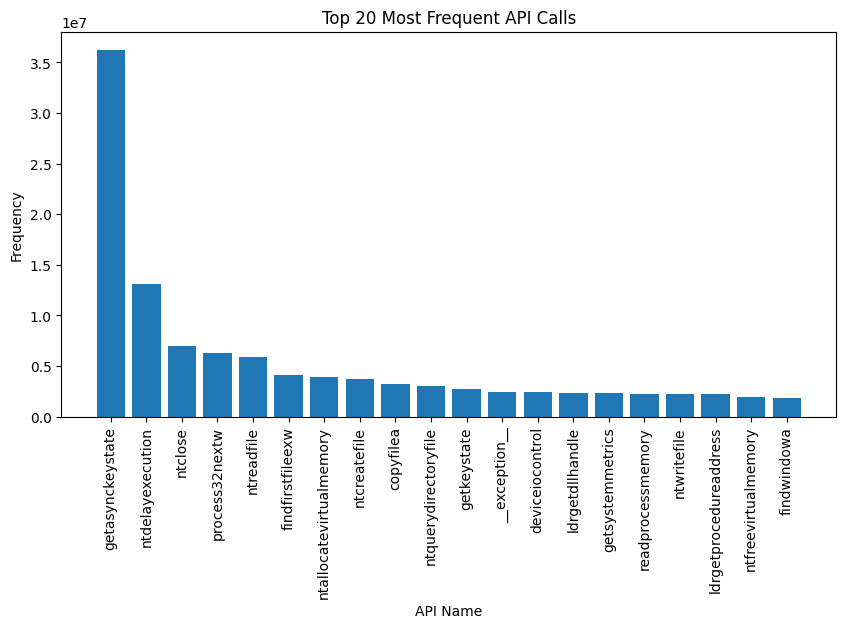

In [73]:
from collections import Counter
import matplotlib.pyplot as plt

all_apis = [api for seq in sequences for api in seq]
api_counts = Counter(all_apis)

top_apis = api_counts.most_common(20)

apis = [api_map.get(x[0], str(x[0])) for x in top_apis]
counts = [x[1] for x in top_apis]

plt.figure(figsize=(10,5))
plt.bar(apis, counts)

plt.xlabel("API Name")
plt.ylabel("Frequency")
plt.title("Top 20 Most Frequent API Calls")

plt.xticks(rotation=90)

plt.savefig("top_api_calls.pdf", bbox_inches='tight')

plt.show()

In [74]:
from google.colab import files
files.download("top_api_calls.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [75]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

max_len = 500   # can tune later

X = pad_sequences(
    sequences,
    maxlen=max_len,
    padding='post',
    truncating='post'
)

print("Shape:", X.shape)

Shape: (7107, 500)


In [76]:
vocab_size = max([max(seq) for seq in sequences]) + 1

/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2922: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/usr/local/lib/python3.12/dist-packages/numpy/lib/_function_base_impl.py:2923: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


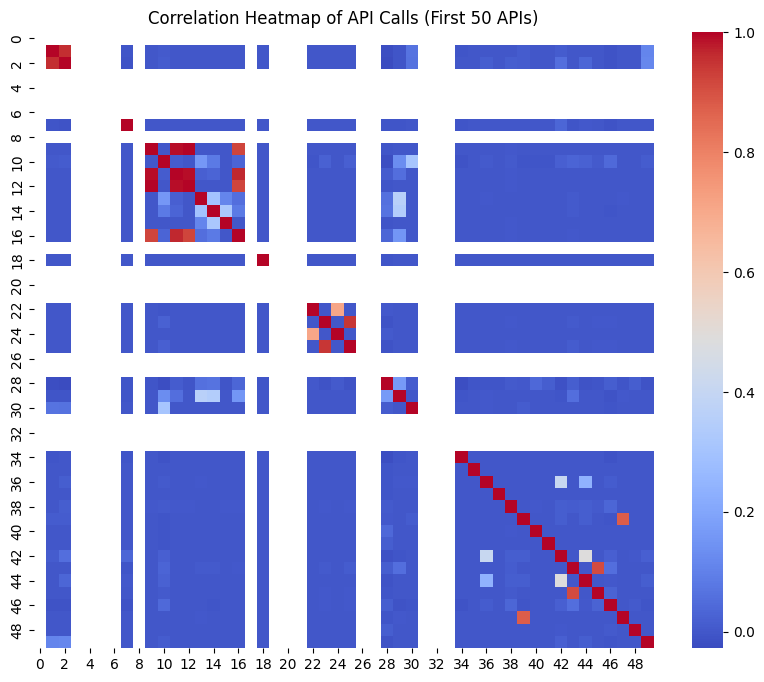

In [77]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

# Convert sequences into frequency matrix
X_freq = np.zeros((len(sequences), vocab_size))

for i, seq in enumerate(sequences):
    for api in seq:

        api = int(api)

        # Ensure index stays within matrix bounds
        if 0 <= api < vocab_size:
            X_freq[i][api] += 1


# Correlation matrix (limit to first 50 APIs)
corr_matrix = np.corrcoef(X_freq[:, :50].T)

plt.figure(figsize=(10,8))

sns.heatmap(
    corr_matrix,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap of API Calls (First 50 APIs)")

plt.savefig(
    "api_correlation_heatmap.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

In [78]:
from google.colab import files
files.download("api_correlation_heatmap.pdf")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

Train shape: (5685, 500)
Test shape: (1422, 500)


In [80]:
vocab_size = max([max(seq) for seq in sequences]) + 1
print("Vocab size:", vocab_size)

Vocab size: 341


In [81]:
import torch

X_train = torch.tensor(X_train, dtype=torch.long)
X_test = torch.tensor(X_test, dtype=torch.long)

y_train = torch.tensor(y_train, dtype=torch.long)
y_test = torch.tensor(y_test, dtype=torch.long)

In [82]:
from torch.utils.data import Dataset, DataLoader

class MalwareDataset(Dataset):
    def __init__(self, X, y):
        self.X = X
        self.y = y

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

train_dataset = MalwareDataset(X_train, y_train)
test_dataset = MalwareDataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64)

In [83]:
import torch.nn as nn

class LSTMClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.lstm = nn.LSTM(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, (hidden, _) = self.lstm(x)
        out = self.fc(hidden[-1])
        return out

In [84]:
model = LSTMClassifier(
    vocab_size=341,
    embed_dim=128,
    hidden_dim=128,
    num_classes=8
)

In [85]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [86]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Using device:", device)

Using device: cuda


In [87]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()

    train_acc = correct / len(train_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {total_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

Epoch 1/5
Loss: 173.8395
Train Accuracy: 0.2339
Epoch 2/5
Loss: 162.6314
Train Accuracy: 0.2909
Epoch 3/5
Loss: 157.2029
Train Accuracy: 0.3108
Epoch 4/5
Loss: 154.8325
Train Accuracy: 0.3201
Epoch 5/5
Loss: 149.8590
Train Accuracy: 0.3418


In [88]:
model.eval()
correct = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y_batch).sum().item()

test_acc = correct / len(test_loader.dataset)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.32841068917018285


***GRU***

In [89]:
import torch.nn as nn

class GRUClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.gru = nn.GRU(embed_dim, hidden_dim, batch_first=True)
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = self.embedding(x)
        _, hidden = self.gru(x)
        out = self.fc(hidden[-1])
        return out

In [90]:
model = GRUClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    hidden_dim=128,
    num_classes=8
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [91]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()

    train_acc = correct / len(train_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {total_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

Epoch 1/5
Loss: 173.8960
Train Accuracy: 0.2375
Epoch 2/5
Loss: 163.3483
Train Accuracy: 0.2931
Epoch 3/5
Loss: 155.6956
Train Accuracy: 0.3172
Epoch 4/5
Loss: 149.8210
Train Accuracy: 0.3502
Epoch 5/5
Loss: 145.1621
Train Accuracy: 0.3789


In [92]:
model.eval()
correct = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y_batch).sum().item()

test_acc = correct / len(test_loader.dataset)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.3509142053445851


***1D CNN***

In [93]:
class CNNClassifier(nn.Module):
    def __init__(self, vocab_size, embed_dim, num_classes):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim)
        self.conv = nn.Conv1d(embed_dim, 128, kernel_size=5)
        self.pool = nn.AdaptiveMaxPool1d(1)
        self.fc = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.embedding(x)              # (batch, seq, embed)
        x = x.permute(0, 2, 1)             # (batch, embed, seq)
        x = self.conv(x)
        x = self.pool(x).squeeze(-1)
        out = self.fc(x)
        return out

In [94]:
model = CNNClassifier(
    vocab_size=vocab_size,
    embed_dim=128,
    num_classes=8
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [95]:
num_epochs = 5

for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    correct = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

        preds = torch.argmax(outputs, dim=1)
        correct += (preds == y_batch).sum().item()

    train_acc = correct / len(train_loader.dataset)

    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"Loss: {total_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

Epoch 1/5
Loss: 145.4597
Train Accuracy: 0.4176
Epoch 2/5
Loss: 114.5280
Train Accuracy: 0.5592
Epoch 3/5
Loss: 100.1684
Train Accuracy: 0.6215
Epoch 4/5
Loss: 90.3060
Train Accuracy: 0.6561
Epoch 5/5
Loss: 83.1498
Train Accuracy: 0.6844


In [96]:
model.eval()
correct = 0

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y_batch).sum().item()

test_acc = correct / len(test_loader.dataset)

print("Test Accuracy:", test_acc)

Test Accuracy: 0.6061884669479606


***RandomForest***

In [97]:
from sklearn.feature_extraction.text import CountVectorizer

seq_strings = [" ".join(map(str, seq)) for seq in sequences]

vectorizer = CountVectorizer()
X_counts = vectorizer.fit_transform(seq_strings)

from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier()
rf.fit(X_counts, y)

print("RF Accuracy:", rf.score(X_counts, y))

RF Accuracy: 0.9935275080906149


In [98]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [99]:
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)

        _, predicted = torch.max(outputs, 1)

        y_true.extend(y_batch.cpu().numpy())
        y_pred.extend(predicted.cpu().numpy())

In [100]:
cm = confusion_matrix(y_true, y_pred)
print(cm)

[[ 59   3   2   6   1   3   2   0]
 [  0 139   4  15  20  18   3   1]
 [  2  21 123  14   5  23   8   4]
 [  0  16   5 105  24  18   9   1]
 [  1  29   3  18  89  13   6   8]
 [  3  58   7  19  19  77  11   6]
 [  0   4   0   5   3  10 174   5]
 [  1  36   5  13   7  28  14  96]]


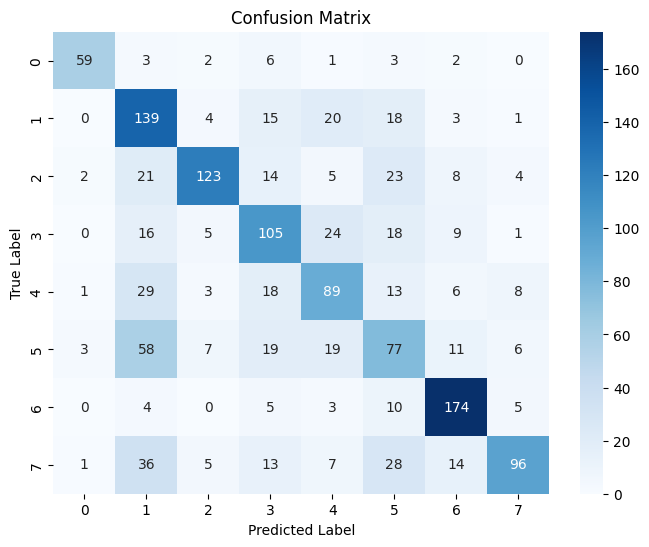

In [101]:
plt.figure(figsize=(8,6))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap='Blues')

plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")

plt.savefig("confusion_matrix.png", dpi=300, bbox_inches='tight')  # saves the image

plt.show()

In [102]:
from google.colab import files
files.download("confusion_matrix.png")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [103]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.78      0.83        76
           1       0.45      0.69      0.55       200
           2       0.83      0.61      0.70       200
           3       0.54      0.59      0.56       178
           4       0.53      0.53      0.53       167
           5       0.41      0.39      0.39       200
           6       0.77      0.87      0.81       201
           7       0.79      0.48      0.60       200

    accuracy                           0.61      1422
   macro avg       0.65      0.62      0.62      1422
weighted avg       0.63      0.61      0.61      1422



In [104]:
from sklearn.metrics import accuracy_score

print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.6061884669479606


***Hyperparameter tuning***

In [105]:
HYPERPARAMS = {
    "embed_dim": [64, 128],
    "hidden_dim": [64, 128],
    "lr": [0.001, 0.0005],
    "batch_size": [32, 64]
}

**Function to train model**

In [106]:
def train_model(embed_dim, hidden_dim, lr, batch_size):

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size)

    model = LSTMClassifier(
        vocab_size=vocab_size,
        embed_dim=embed_dim,
        hidden_dim=hidden_dim,
        num_classes=8
    ).to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    num_epochs = 5

    for epoch in range(num_epochs):

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)

            loss.backward()
            optimizer.step()

    # evaluation

    model.eval()

    correct = 0

    with torch.no_grad():

        for X_batch, y_batch in test_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = model(X_batch)
            preds = torch.argmax(outputs, dim=1)

            correct += (preds == y_batch).sum().item()

    acc = correct / len(test_loader.dataset)

    return acc

**Grid search tuning**

In [107]:
results = []

for embed_dim in HYPERPARAMS["embed_dim"]:
    for hidden_dim in HYPERPARAMS["hidden_dim"]:
        for lr in HYPERPARAMS["lr"]:
            for batch_size in HYPERPARAMS["batch_size"]:

                print("Testing:",
                      embed_dim,
                      hidden_dim,
                      lr,
                      batch_size)

                acc = train_model(
                    embed_dim,
                    hidden_dim,
                    lr,
                    batch_size
                )

                results.append({
                    "embed_dim": embed_dim,
                    "hidden_dim": hidden_dim,
                    "lr": lr,
                    "batch_size": batch_size,
                    "accuracy": acc
                })

                print("Accuracy:", acc)

Testing: 64 64 0.001 32
Accuracy: 0.3263009845288326
Testing: 64 64 0.001 64
Accuracy: 0.3073136427566807
Testing: 64 64 0.0005 32
Accuracy: 0.3143459915611814
Testing: 64 64 0.0005 64
Accuracy: 0.27918424753867793
Testing: 64 128 0.001 32
Accuracy: 0.3263009845288326
Testing: 64 128 0.001 64
Accuracy: 0.3171589310829817
Testing: 64 128 0.0005 32
Accuracy: 0.30239099859353025
Testing: 64 128 0.0005 64
Accuracy: 0.31223628691983124
Testing: 128 64 0.001 32
Accuracy: 0.3333333333333333
Testing: 128 64 0.001 64
Accuracy: 0.34458509142053445
Testing: 128 64 0.0005 32
Accuracy: 0.31926863572433195
Testing: 128 64 0.0005 64
Accuracy: 0.32841068917018285
Testing: 128 128 0.001 32
Accuracy: 0.3389592123769339
Testing: 128 128 0.001 64
Accuracy: 0.34247538677918427
Testing: 128 128 0.0005 32
Accuracy: 0.3340365682137834
Testing: 128 128 0.0005 64
Accuracy: 0.3073136427566807


In [108]:
results_df = pd.DataFrame(results)

print(results_df)

best = results_df.sort_values(
    by="accuracy",
    ascending=False
).iloc[0]

print("\nBest params:")
print(best)

    embed_dim  hidden_dim      lr  batch_size  accuracy
0          64          64  0.0010          32  0.326301
1          64          64  0.0010          64  0.307314
2          64          64  0.0005          32  0.314346
3          64          64  0.0005          64  0.279184
4          64         128  0.0010          32  0.326301
5          64         128  0.0010          64  0.317159
6          64         128  0.0005          32  0.302391
7          64         128  0.0005          64  0.312236
8         128          64  0.0010          32  0.333333
9         128          64  0.0010          64  0.344585
10        128          64  0.0005          32  0.319269
11        128          64  0.0005          64  0.328411
12        128         128  0.0010          32  0.338959
13        128         128  0.0010          64  0.342475
14        128         128  0.0005          32  0.334037
15        128         128  0.0005          64  0.307314

Best params:
embed_dim     128.000000
hidden_di

In [109]:
best_embed = int(best["embed_dim"])
best_hidden = int(best["hidden_dim"])
best_lr = float(best["lr"])
best_batch = int(best["batch_size"])

train_loader = DataLoader(
    train_dataset,
    batch_size=best_batch,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=best_batch
)

model = LSTMClassifier(
    vocab_size=vocab_size,
    embed_dim=best_embed,
    hidden_dim=best_hidden,
    num_classes=8
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=best_lr)

num_epochs = 20

for epoch in range(num_epochs):

    model.train()

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)

        loss.backward()
        optimizer.step()

    print("Epoch", epoch+1, "done")

Epoch 1 done
Epoch 2 done
Epoch 3 done
Epoch 4 done
Epoch 5 done
Epoch 6 done
Epoch 7 done
Epoch 8 done
Epoch 9 done
Epoch 10 done
Epoch 11 done
Epoch 12 done
Epoch 13 done
Epoch 14 done
Epoch 15 done
Epoch 16 done
Epoch 17 done
Epoch 18 done
Epoch 19 done
Epoch 20 done


In [110]:
model.eval()

correct = 0

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1)

        correct += (preds == y_batch).sum().item()

final_acc = correct / len(test_loader.dataset)

print("Final tuned accuracy:", final_acc)

Final tuned accuracy: 0.3431786216596343


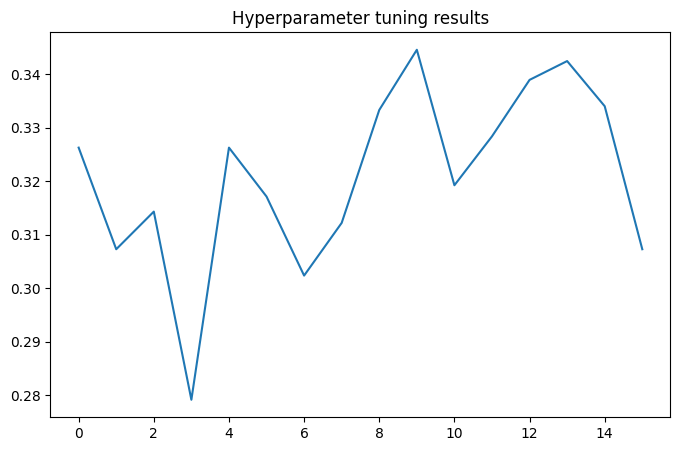

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [111]:
plt.figure(figsize=(8,5))

plt.plot(results_df["accuracy"])

plt.title("Hyperparameter tuning results")

plt.savefig(
    "hyperparameter_tuning_results.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

from google.colab import files
files.download("hyperparameter_tuning_results.pdf")